In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
sb.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
df = pd.read_csv(r"../../Data/Raw/GameplayData.csv")

print('-'*20)
print('DATA LOADED')
print('-'*20)

print(f"Shape: {df.shape} \n")
print(f"First few rows: \n")
df.head()

--------------------
DATA LOADED
--------------------
Shape: (180, 24) 

First few rows: 



,sessionID,playerID,gameType,difficultyLevel,sessionDuration,score,deaths,completed,timestamp,victory,combosExecuted,perfectDodges,hitsDealt,hitsTaken,playerAccuracy,avgReactionTime,lapsCompleted,bestLapTime,avgLapTime,totalRaceTime,collisions,maxSpeed,avgSpeed,consistency
0,57d4c399-8611-484f-823a-c68273d914c0,1,Fighting,Easy,16.14,2400,0,True,11/1/2026 16:53,True,6.0,3.0,10.0,0.0,1.000000,0.882287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9ce3b181-5421-4501-a8bb-31ccd9f62020,1,Fighting,Medium,33.13,2950,0,True,11/1/2026 16:54,True,6.0,10.0,13.0,2.0,1.000000,0.551105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,f839957b-f8cb-48c7-96bb-9c4e2d33563c,1,Fighting,Hard,49.10,2655,0,True,11/1/2026 16:55,True,7.0,7.0,20.0,1.0,0.909091,0.484453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6acaeffc-f45b-46a3-a874-15edfaabe957,1,Racing,Easy,153.04,1050,0,True,11/1/2026 16:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,50.57998,51.01185,153.0356,1.0,30.0,29.80731,0.990413
4,cebdef88-7877-43ef-bc35-70692e4fe106,1,Racing,Medium,122.30,600,0,True,11/1/2026 17:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,39.57999,40.76645,122.2993,10.0,40.0,37.64244,0.967751


In [4]:
print('-'*20)
print('DATASET INFO')
print('-'*20)

print(f"Total records: {len(df)}\n")
print(f"Number of columns: {len(df.columns)}\n")
print(f"Column names and types:")
print(df.dtypes)

--------------------
DATASET INFO
--------------------
Total records: 180

Number of columns: 24

Column names and types:
sessionID           object
playerID             int64
gameType            object
difficultyLevel     object
sessionDuration    float64
score                int64
deaths               int64
completed             bool
timestamp           object
victory             object
combosExecuted     float64
perfectDodges      float64
hitsDealt          float64
hitsTaken          float64
playerAccuracy     float64
avgReactionTime    float64
lapsCompleted      float64
bestLapTime        float64
avgLapTime         float64
totalRaceTime      float64
collisions         float64
maxSpeed           float64
avgSpeed           float64
consistency        float64
dtype: object


In [5]:
print('-'*20)
print('MISSING VALUES')
print('-'*20)

missing = df.isnull().sum()
missing_pct = missing/len(df) * 100

print(f"Number of missing values: \n{missing}")
print(f"Percentage missing: \n{missing_pct}")

--------------------
MISSING VALUES
--------------------
Number of missing values: 
sessionID           0
playerID            0
gameType            0
difficultyLevel     0
sessionDuration     0
score               0
deaths              0
completed           0
timestamp           0
victory            90
combosExecuted     90
perfectDodges      90
hitsDealt          90
hitsTaken          90
playerAccuracy     90
avgReactionTime    90
lapsCompleted      90
bestLapTime        90
avgLapTime         90
totalRaceTime      90
collisions         90
maxSpeed           90
avgSpeed           90
consistency        90
dtype: int64
Percentage missing: 
sessionID           0.0
playerID            0.0
gameType            0.0
difficultyLevel     0.0
sessionDuration     0.0
score               0.0
deaths              0.0
completed           0.0
timestamp           0.0
victory            50.0
combosExecuted     50.0
perfectDodges      50.0
hitsDealt          50.0
hitsTaken          50.0
playerAccuracy    

In [6]:
print('-'*20)
print('RECORD COUNT')
print('-'*20)

print(f"Records per game: ")
print(df['gameType'].value_counts())

print(f"\nRecords per difficulty level:")
print(df["difficultyLevel"].value_counts())

balance_check = df.groupby(['gameType', 'difficultyLevel']).size().reset_index(name='count')
print(f'\n{balance_check}')

--------------------
RECORD COUNT
--------------------
Records per game: 
gameType
Fighting    90
Racing      90
Name: count, dtype: int64

Records per difficulty level:
difficultyLevel
Easy      60
Medium    60
Hard      60
Name: count, dtype: int64

   gameType difficultyLevel  count
0  Fighting            Easy     30
1  Fighting            Hard     30
2  Fighting          Medium     30
3    Racing            Easy     30
4    Racing            Hard     30
5    Racing          Medium     30


In [7]:
print('-'*20)
print('GENERAL STATISTICS')
print('-'*20)

df.describe()

--------------------
GENERAL STATISTICS
--------------------


,playerID,sessionDuration,score,deaths,combosExecuted,perfectDodges,hitsDealt,hitsTaken,playerAccuracy,avgReactionTime,lapsCompleted,bestLapTime,avgLapTime,totalRaceTime,collisions,maxSpeed,avgSpeed,consistency
count,180.000000,180.000000,180.000000,180.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,15.494444,81.656889,1383.750000,0.211111,4.988889,6.755556,11.711111,4.255556,0.829445,0.466215,2.855556,41.918929,42.674886,125.345287,12.966667,38.333333,36.202806,0.983292
std,8.681514,50.444369,1076.473603,0.409235,3.003722,6.376416,3.787159,3.299851,0.150776,0.396767,0.509706,8.410474,8.492379,26.752263,12.555003,6.271032,5.645983,0.014288
min,1.000000,15.340000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.428571,0.000000,0.000000,0.000000,0.000000,37.107450,0.000000,30.000000,26.127400,0.941961
25%,8.000000,35.840000,500.000000,0.000000,3.000000,1.250000,10.000000,1.000000,0.753676,0.193606,3.000000,35.594972,36.355378,107.910150,2.000000,30.000000,29.808968,0.973821
50%,15.500000,70.875000,1025.000000,0.000000,5.000000,4.000000,10.000000,4.000000,0.848077,0.343765,3.000000,38.759985,39.749590,118.908000,11.000000,40.000000,38.355210,0.988576
75%,23.000000,119.020000,2362.500000,0.000000,7.000000,11.000000,13.000000,8.000000,0.940476,0.703368,3.000000,50.374952,50.955568,152.757400,17.750000,45.000000,40.151492,0.993971
max,30.000000,203.910000,4000.000000,1.000000,13.000000,26.000000,20.000000,10.000000,1.000000,1.473244,3.000000,57.819980,59.312170,177.936500,59.000000,45.000000,44.257710,1.000000


In [52]:
racing_metrics = [
    'sessionDuration', 'score', 'deaths', 'lapsCompleted',
    'bestLapTime', 'avgLapTime', 'totalRaceTime', 
    'collisions', 'maxSpeed', 'avgSpeed', 'consistency'
]

fighting_metrics = [
    'sessionDuration', 'score', 'deaths', 'victory',
    'combosExecuted', 'perfectDodges', 'hitsDealt', 
    'hitsTaken', 'playerAccuracy', 'avgReactionTime'
]

print('-'*20)
print('FIGHTING GAME')
print('-'*20)

fighting_df = df[df['gameType'] == 'Fighting'].drop(columns=racing_metrics)

existing_metrics = [col for col in fighting_metrics if col in fighting_df.columns]
print(f"\nAvailable metrics: {existing_metrics}")

print("\nFighting Game Statistics by Difficulty:")
fighting_df.groupby('difficultyLevel')[existing_metrics].mean()

--------------------
FIGHTING GAME
--------------------

Available metrics: ['victory', 'combosExecuted', 'perfectDodges', 'hitsDealt', 'hitsTaken', 'playerAccuracy', 'avgReactionTime']

Fighting Game Statistics by Difficulty:


,victory,combosExecuted,perfectDodges,hitsDealt,hitsTaken,playerAccuracy,avgReactionTime
difficultyLevel,,,,,,,
Easy,1.0,5.566667,2.733333,10.000000,1.300000,0.849654,0.834749
Hard,0.233333,4.700000,9.700000,12.800000,6.466667,0.840364,0.243638
Medium,0.766667,4.700000,7.833333,12.333333,5.000000,0.798315,0.320258


In [54]:
print("-"*20)
print("RACING GAME METRICS")
print("-"*20)

racing_df = df[df['gameType'] == 'Racing'].drop(columns=fighting_metrics)

existing_metrics = [col for col in racing_metrics if col in racing_df.columns]
print(f"\nAvailable metrics: {existing_metrics}")

print("\nRacing Game Statistics by Difficulty:")
racing_df.groupby('difficultyLevel')[existing_metrics].mean()

--------------------
RACING GAME METRICS
--------------------

Available metrics: ['lapsCompleted', 'bestLapTime', 'avgLapTime', 'totalRaceTime', 'collisions', 'maxSpeed', 'avgSpeed', 'consistency']

Racing Game Statistics by Difficulty:


,lapsCompleted,bestLapTime,avgLapTime,totalRaceTime,collisions,maxSpeed,avgSpeed,consistency
difficultyLevel,,,,,,,,
Easy,3.000000,50.716283,51.349436,154.048307,2.333333,30.0,29.631061,0.988978
Hard,2.700000,35.488921,36.338766,105.055729,23.433333,45.0,40.809538,0.979913
Medium,2.866667,39.551582,40.336457,116.931827,13.133333,40.0,38.167819,0.980985


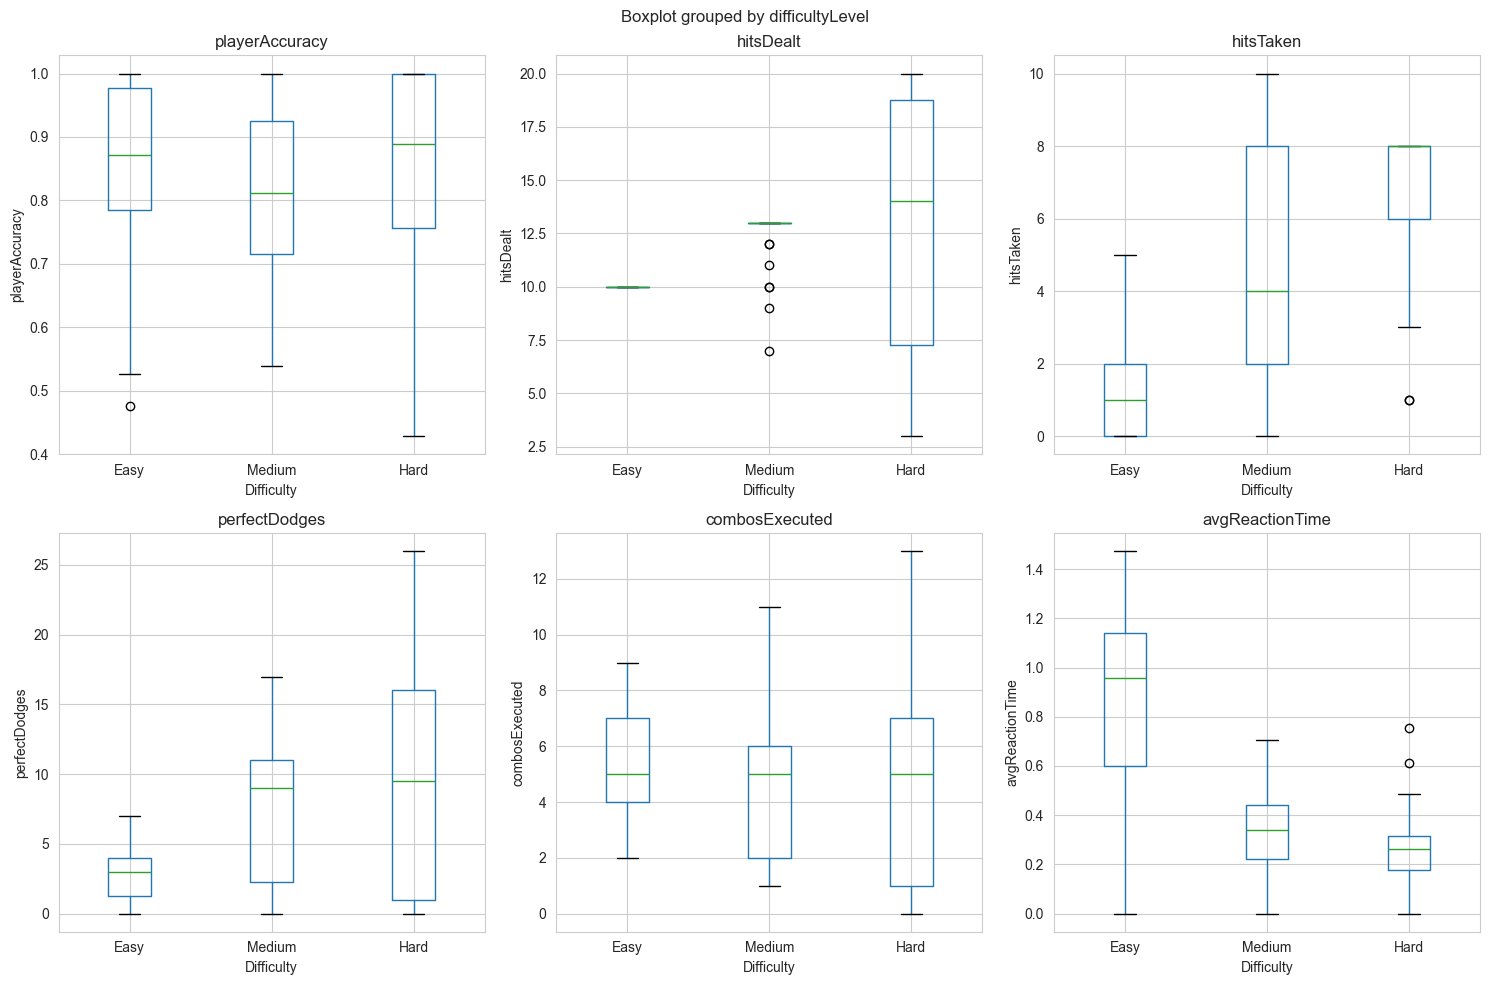

In [43]:
# Visualize fighting game metrics across difficulties

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Fighting Game: Metrics Across Difficulty Levels', fontsize=16)

metrics_to_plot = ['playerAccuracy', 'hitsDealt', 'hitsTaken', 
                    'perfectDodges', 'combosExecuted', 'avgReactionTime']

for idx, metric in enumerate(metrics_to_plot):
    if metric in fighting_df.columns:
        row = idx // 3
        col = idx % 3
        
        fighting_df.boxplot(column=metric, by='difficultyLevel', ax=axes[row, col])
        axes[row, col].set_title(metric)
        axes[row, col].set_xlabel('Difficulty')
        axes[row, col].set_ylabel(metric)

plt.tight_layout()
plt.show()

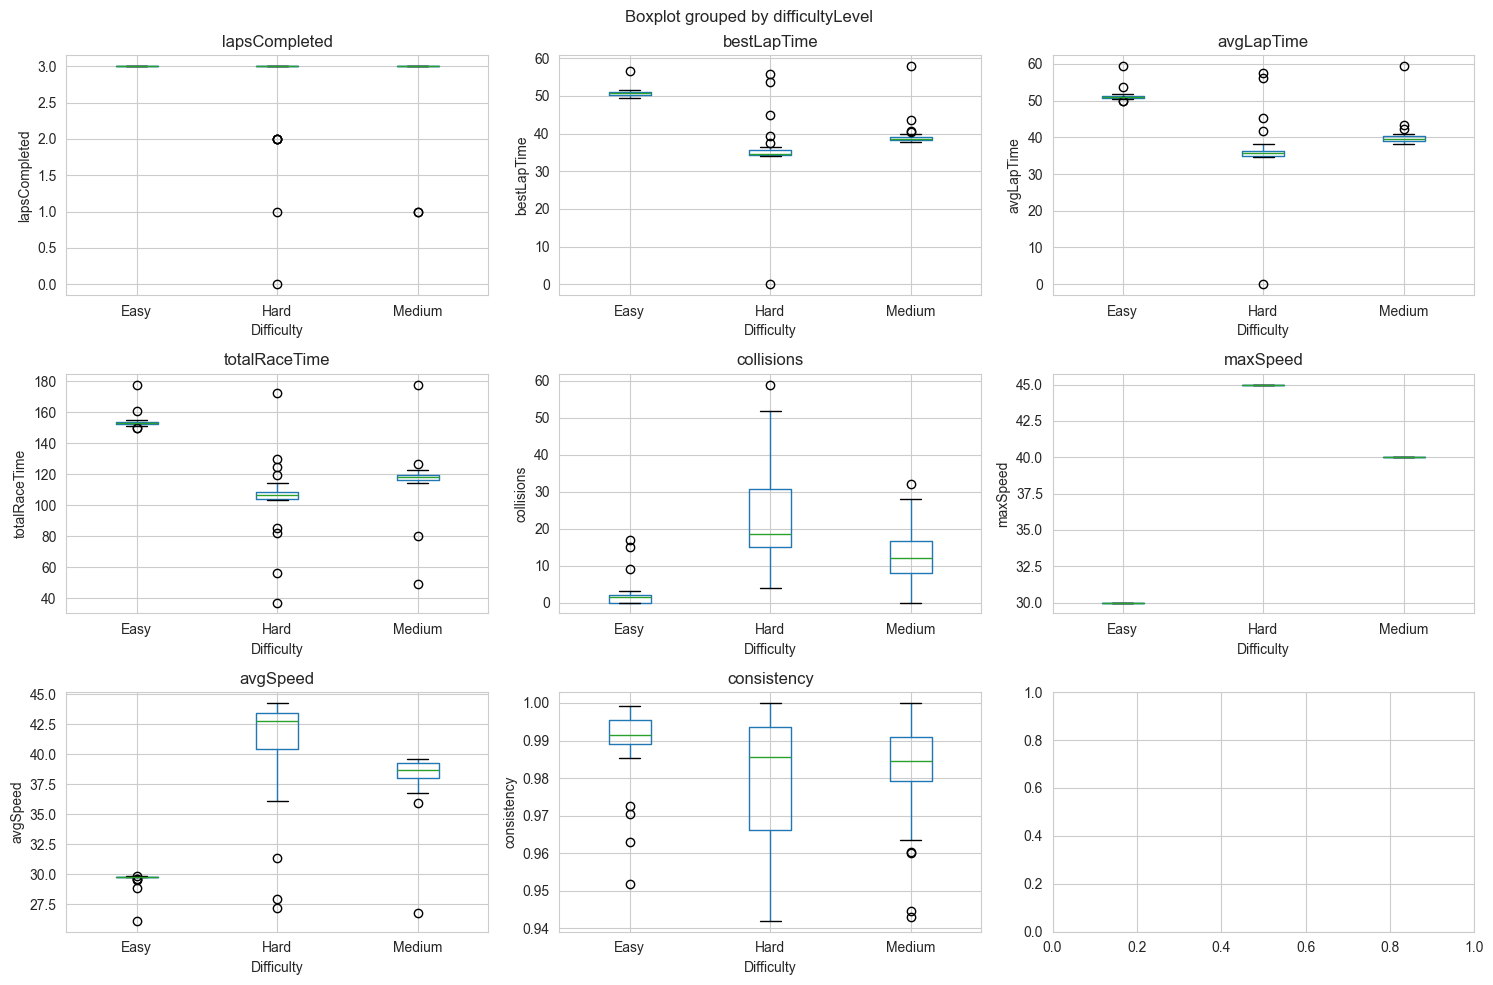

In [60]:
# Visualize racing game metrics across difficulties

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Racing Game: Metrics Across Difficulty Levels', fontsize=16)

metrics_to_plot = ['lapsCompleted', 'bestLapTime', 'avgLapTime', 'totalRaceTime', 'collisions', 
                    'maxSpeed', 'avgSpeed', 'consistency']

for idx, metric in enumerate(metrics_to_plot):
    if metric in racing_df.columns:
        row = idx // 3
        col = idx % 3
        
        racing_df.boxplot(column=metric, by='difficultyLevel', ax=axes[row, col])
        axes[row, col].set_title(metric)
        axes[row, col].set_xlabel('Difficulty')
        axes[row, col].set_ylabel(metric)

plt.tight_layout()
plt.show()

COMPLETION RATE ANALYSIS
   gameType difficultyLevel  Total  Completed  Completion_Rate
0  Fighting            Easy     30         30         1.000000
1  Fighting            Hard     30         30         1.000000
2  Fighting          Medium     30         30         1.000000
3    Racing            Easy     30         30         1.000000
4    Racing            Hard     30         24         0.800000
5    Racing          Medium     30         28         0.933333


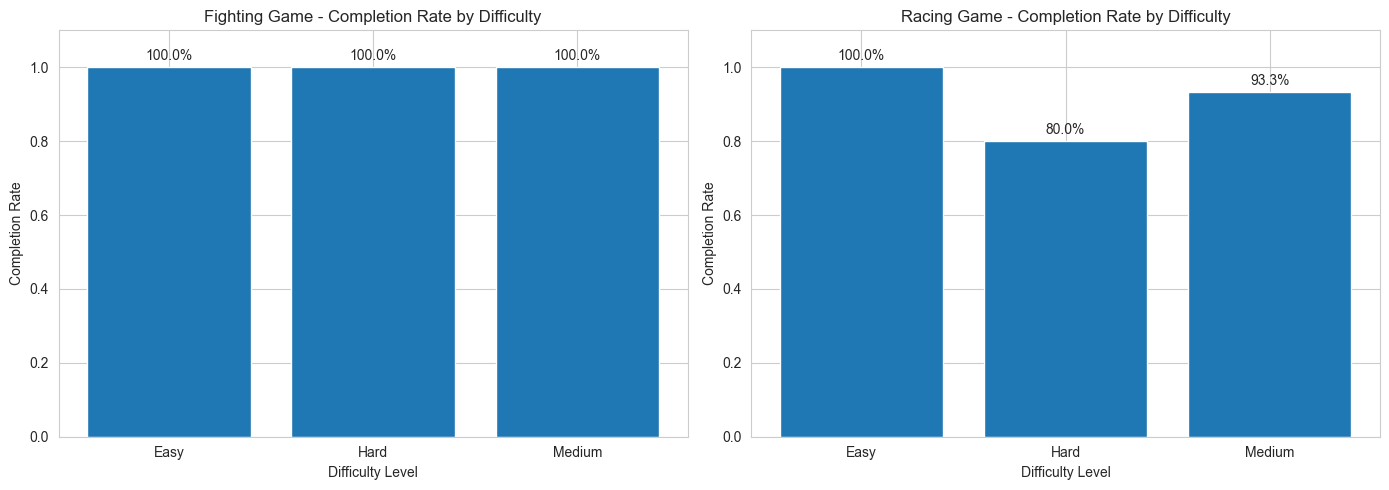

In [61]:
# Analyze completion rates across difficulties
print("="*50)
print("COMPLETION RATE ANALYSIS")
print("="*50)

completion_stats = df.groupby(['gameType', 'difficultyLevel'])['completed'].agg([
    ('Total', 'count'),
    ('Completed', 'sum'),
    ('Completion_Rate', 'mean')
]).reset_index()

print(completion_stats)

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for idx, game in enumerate(['Fighting', 'Racing']):
    game_data = completion_stats[completion_stats['gameType'] == game]
    
    ax[idx].bar(game_data['difficultyLevel'].astype(str), 
                game_data['Completion_Rate'])
    ax[idx].set_title(f'{game} Game - Completion Rate by Difficulty')
    ax[idx].set_xlabel('Difficulty Level')
    ax[idx].set_ylabel('Completion Rate')
    ax[idx].set_ylim([0, 1.1])
    
    # Add percentage labels on bars
    for i, v in enumerate(game_data['Completion_Rate']):
        ax[idx].text(i, v + 0.02, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.show()

FIGHTING GAME: VICTORY RATES
                 Total_Fights Victories Victory_Rate
difficultyLevel                                     
Easy                       30        30          1.0
Medium                     30        23     0.766667
Hard                       30         7     0.233333


C:\Users\Admin\AppData\Local\Temp\ipykernel_16496\260468261.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  victory_stats = fighting_df.groupby('difficultyLevel')['victory'].agg([


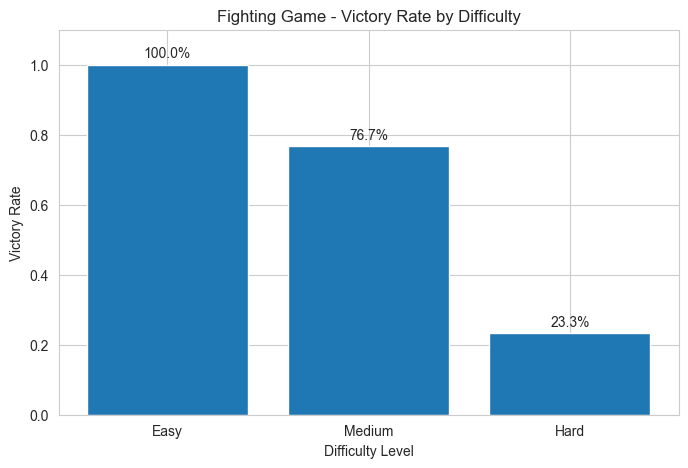

In [46]:
# Fighting game victory analysis
if 'victory' in fighting_df.columns:
    print("="*50)
    print("FIGHTING GAME: VICTORY RATES")
    print("="*50)
    
    victory_stats = fighting_df.groupby('difficultyLevel')['victory'].agg([
        ('Total_Fights', 'count'),
        ('Victories', 'sum'),
        ('Victory_Rate', 'mean')
    ])
    
    print(victory_stats)
    
    # Visualize
    plt.figure(figsize=(8, 5))
    plt.bar(victory_stats.index.astype(str), victory_stats['Victory_Rate'])
    plt.title('Fighting Game - Victory Rate by Difficulty')
    plt.xlabel('Difficulty Level')
    plt.ylabel('Victory Rate')
    plt.ylim([0, 1.1])
    
    for i, v in enumerate(victory_stats['Victory_Rate']):
        plt.text(i, v + 0.02, f'{v*100:.1f}%', ha='center')
    
    plt.show()

In [38]:
# Detect outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("="*50)
print("OUTLIER DETECTION")
print("="*50)

# Check key metrics for outliers
metrics_to_check = ['sessionDuration', 'score']

for metric in metrics_to_check:
    if metric in df.columns:
        outliers, lower, upper = detect_outliers(df, metric)
        print(f"\n{metric}:")
        print(f"  Valid range: [{lower:.2f}, {upper:.2f}]")
        print(f"  Outliers found: {len(outliers)}")
        
        if len(outliers) > 0:
            print(f"  Outlier values: {outliers[metric].values}")

OUTLIER DETECTION

sessionDuration:
  Valid range: [-88.93, 243.79]
  Outliers found: 0

score:
  Valid range: [-2293.75, 5156.25]
  Outliers found: 0


FIGHTING GAME: CORRELATION ANALYSIS


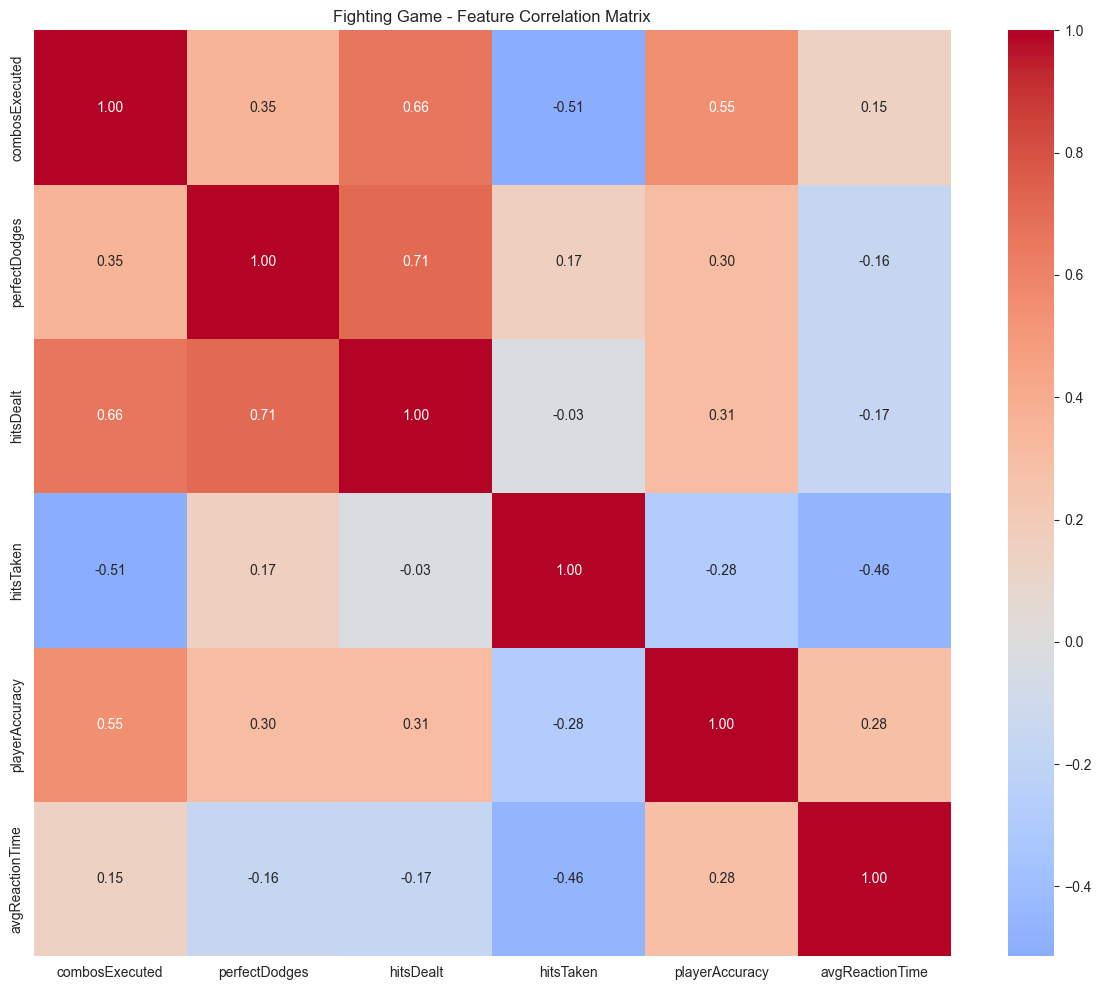

In [62]:
# Correlation heatmap for fighting game
print("="*50)
print("FIGHTING GAME: CORRELATION ANALYSIS")
print("="*50)

fighting_numeric = fighting_df.select_dtypes(include=[np.number])

# Remove non-metric columns
cols_to_exclude = ['sessionID', 'playerID', 'Unnamed: 0'] if 'Unnamed: 0' in fighting_numeric.columns else ['sessionID', 'playerID']
fighting_numeric = fighting_numeric.drop(columns=[col for col in cols_to_exclude if col in fighting_numeric.columns])

plt.figure(figsize=(12, 10))
sb.heatmap(fighting_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Fighting Game - Feature Correlation Matrix')
plt.tight_layout()
plt.show()

RACING GAME: CORRELATION ANALYSIS


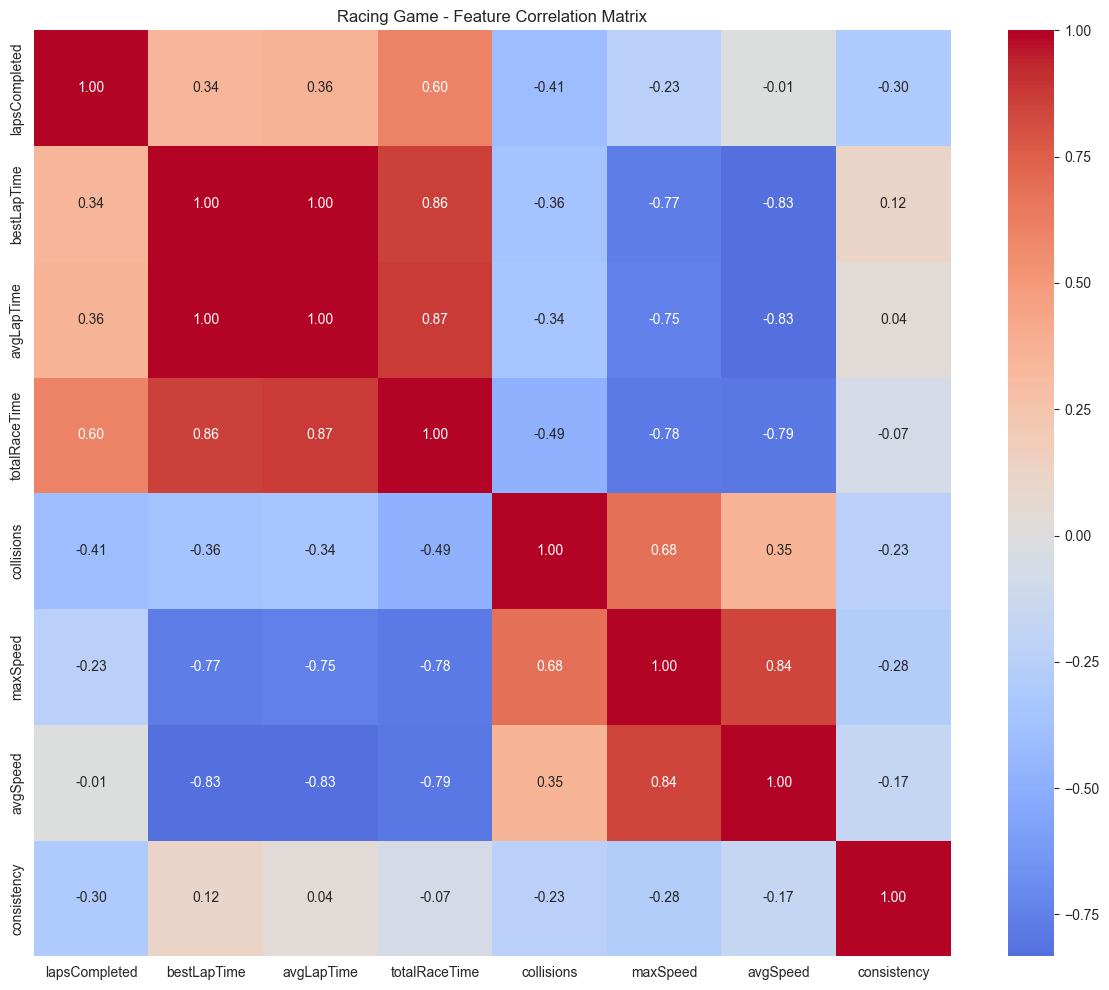

In [64]:
# Correlation heatmap for racing game
print("="*50)
print("RACING GAME: CORRELATION ANALYSIS")
print("="*50)

racing_numeric = racing_df.select_dtypes(include=[np.number])

# Remove non-metric columns
cols_to_exclude = ['sessionID', 'playerID', 'Unnamed: 0'] if 'Unnamed: 0' in racing_numeric.columns else ['sessionID', 'playerID']
racing_numeric = racing_numeric.drop(columns=[col for col in cols_to_exclude if col in racing_numeric.columns])

plt.figure(figsize=(12, 10))
sb.heatmap(racing_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Racing Game - Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [65]:
# Final data quality report
print("="*80)
print("DATA QUALITY SUMMARY REPORT")
print("="*80)

report = {
    'Total Records': len(df),
    'Expected Records': '180 (30 players × 2 games × 3 difficulties)',
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Records': df.duplicated().sum(),
    'Unique Players': df['playerID'].nunique(),
    'Game Types': df['gameType'].nunique(),
    'Difficulty Levels': df['difficultyLevel'].nunique(),
    'Data Balance': 'Balanced' if all(df.groupby(['gameType', 'difficultyLevel']).size() == 30) else 'Imbalanced'
}

for key, value in report.items():
    print(f"{key:.<40} {value}")

print("\n" + "="*80)
print("NEXT STEPS:")
print("="*80)
print("1. If data quality is good → Proceed to feature engineering")
print("2. If outliers found → Investigate and decide on handling strategy")
print("3. If missing values → Determine imputation or removal strategy")
print("4. Document any data quality issues for FYP report")

DATA QUALITY SUMMARY REPORT
Total Records........................... 180
Expected Records........................ 180 (30 players × 2 games × 3 difficulties)
Missing Values.......................... 1350
Duplicate Records....................... 0
Unique Players.......................... 30
Game Types.............................. 2
Difficulty Levels....................... 3
Data Balance............................ Balanced

NEXT STEPS:
1. If data quality is good → Proceed to feature engineering
2. If outliers found → Investigate and decide on handling strategy
3. If missing values → Determine imputation or removal strategy
4. Document any data quality issues for FYP report
